<table>
    <tr>
        <td><img src="../logo/Macc.png" width="auto"/></td>
        <td>
            <table><tr>
            <h1 style="color:blue;text-align:center">Teoría de Grafos</h1></td>
            </tr></table>   
        <td>&nbsp;</td>
        <td>
            <table><tr>
            <tp><h1 style="font-size:150%;text-align:center">SIMULACIÓN Y VISUALIZACIÓN MODELO SIS (COVID-19)</h1></tp>
            <tp><h1 style="font-size:150%;text-align:center">Proyecto</h1></tp>
            <p style="font-size:150%;text-align:left">Juan Felipe Rojas Manjarres</p>
            <p style="font-size:150%;text-align:left">Juan Felipe Amaya Montaña</p>
            <p style="font-size:150%;text-align:left">Sebastian Alejandro Sanchez Urrego</p>
            </tr></table>
        </td>
    </tr>
</table>

<h2>1. Importación de celdas y rutas</h2>

In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import time

from IPython.display import clear_output

# 👇 Muy importante: como el notebook está en src/,
# el ROOT es la carpeta padre (el proyecto):
ROOT = Path.cwd().parents[0]

P    = ROOT / "data" / "processed"
RES  = ROOT / "results"
FIGS = ROOT / "figs"

RES.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

ROOT, P, RES, FIGS

(WindowsPath('C:/Users/juanf/OneDrive/Documentos/UR/2025-2/grafos me lo tiro/PersonaContagios/PersonaContagios'),
 WindowsPath('C:/Users/juanf/OneDrive/Documentos/UR/2025-2/grafos me lo tiro/PersonaContagios/PersonaContagios/data/processed'),
 WindowsPath('C:/Users/juanf/OneDrive/Documentos/UR/2025-2/grafos me lo tiro/PersonaContagios/PersonaContagios/results'),
 WindowsPath('C:/Users/juanf/OneDrive/Documentos/UR/2025-2/grafos me lo tiro/PersonaContagios/PersonaContagios/figs'))

<h2>Carga de datos y simulación del modelo SIS</h2>

In [2]:
# Cargar datos base
nodes    = pd.read_csv(P/"nodes.csv")
contacts = pd.read_csv(P/"contacts.csv")

# Asegurar tipos string para ids
nodes["id"]        = nodes["id"].astype(str)
contacts["source"] = contacts["source"].astype(str)
contacts["target"] = contacts["target"].astype(str)

# Parámetros SIS (IGUALES al script que sí te funcionaba)
beta  = 0.5    # contagio por ventana
delta = 0.02   # recuperación por ventana
seed_schedule = {0: 10, 40: 50, 120: 25}   # mismo esquema de siembra

# Horizonte temporal: igual que en el script original
T = int(contacts["t_end"].max()) if len(contacts) > 0 else 0

# Agrupar contactos por ventana t_start
by_t = {t: g for t, g in contacts.groupby("t_start")}

# Estado inicial: 0 = S, 1 = I
state = {v: 0 for v in nodes["id"]}

# RNG reproducible
rng = random.Random(11)

def reseed(k):
    """Infecta aleatoriamente k nodos susceptibles."""
    S = [v for v, s in state.items() if s == 0]
    for v in rng.sample(S, min(k, len(S))):
        state[v] = 1

# Siembra inicial en t = 0
if 0 in seed_schedule:
    reseed(seed_schedule[0])

infection_edges = []
series = []

# Bucle en el tiempo: t = 1, 2, ..., T
for t in range(1, T + 1):
    # Siembras adicionales (brotes) en tiempos específicos
    if t in seed_schedule and t != 0:
        reseed(seed_schedule[t])

    # Recuperaciones I -> S
    for v in list(state.keys()):
        if state[v] == 1 and rng.random() < delta:
            state[v] = 0

    # Contactos en la ventana t
    g = by_t.get(t)
    if g is not None and len(g) > 0:
        Gt = nx.from_pandas_edgelist(g, "source", "target")
        newly = []

        for v in Gt.nodes():
            if state[v] == 0:  # v susceptible
                # vecinos infectados de v en esta ventana
                inf_nbrs = [u for u in Gt.neighbors(v) if state[u] == 1]
                if not inf_nbrs:
                    continue

                # tiempo total de exposición de v en esta ventana
                w_total = g.query("source == @v or target == @v")["weight"].sum()

                # número de bloques ~ cuántas "exposiciones de 20s" equivalentes
                blocks = max(1, int(round(w_total / 20)))

                # prob. de contagio acumulada: p = 1 - (1-beta)^blocks
                p = 1 - (1 - beta)**blocks

                # moneda cargada con probabilidad p
                if rng.random() < p:
                    # elegimos qué vecino infectado fue la fuente
                    u = rng.choice(inf_nbrs)
                    newly.append((u, v))

        # Aplicar infecciones de esta ventana
        for (u, v) in newly:
            if state[v] == 0:
                state[v] = 1
                infection_edges.append((u, v, t))

    # Contar S e I en esta ventana
    I = sum(1 for s in state.values() if s == 1)
    S = len(state) - I
    series.append((t, S, I))

# DataFrames finales
inf = pd.DataFrame(infection_edges, columns=["source", "target", "t_infect"])\
        .assign(weight=lambda d: d["t_infect"], directed=True)

series = pd.DataFrame(series, columns=["t", "S", "I"])

# Guardar en results/ usando ROOT/RES
inf.to_csv(RES/"infection_edges.csv", index=False)
series.to_csv(RES/"states_by_t.csv", index=False)

print("Listo SIS en notebook:", len(inf), "contagios, T =", T)

Listo SIS en notebook: 375 contagios, T = 36477


<H2>3. Definición de Layouts y colores para la visualización de los snapshots</H2>

In [3]:
# --- Preparar escala de colores por tiempo de infección ---
# Tiempo mínimo y máximo de infección observados
if len(inf) > 0:
    TMIN_INF = int(inf["t_infect"].min())
    TMAX_INF = int(inf["t_infect"].max())
else:
    TMIN_INF, TMAX_INF = 0, 1

# Grafo de contactos para obtener layout consistente
G_layout = nx.from_pandas_edgelist(
    contacts, "source", "target", create_using=nx.Graph()
)

# Garantizar que todos los nodos están en el layout
G_layout.add_nodes_from(nodes["id"].tolist())

# Layout global
pos = nx.spring_layout(G_layout, seed=7)


cmap_time = plt.colormaps["plasma"]
norm_time = plt.Normalize(vmin=TMIN_INF, vmax=TMAX_INF)

# Tiempo de PRIMERA infección por nodo (para colorear nodos)
first_inf = inf.groupby("target")["t_infect"].min().to_dict()

def color_by_time(v, t_cut):
    """
    Color del nodo v según su tiempo de primera infección.
    - Si aún no se ha infectado para t_cut -> gris.
    - Si ya se infectó -> color de la escala plasma según t_infect.
    """
    ti = first_inf.get(v, None)
    if (ti is None) or (ti > t_cut):
        return "#d9d9d9"
    return cmap_time(norm_time(ti))

<h2>4. Creación de funciones para dibujar los snapshots</h2>

In [4]:
def draw_snapshot(t_cut, save=False):
    """
    Dibuja la red de contagios acumulada hasta t_cut,
    con nodos coloreados por tiempo de infección y
    barra de color a la derecha.
    
    Devuelve fig para poder usar display(fig) en Jupyter.
    """
    # Subconjunto de aristas de contagio hasta t_cut
    sub = inf[inf["t_infect"] <= t_cut]

    H = nx.DiGraph()
    ids = nodes["id"].astype(str).tolist()
    H.add_nodes_from(ids)

    for r in sub.itertuples():
        H.add_edge(r.source, r.target, t_infect=int(r.t_infect))

    # Colores de nodos
    node_colors = [color_by_time(v, t_cut) for v in ids]

    # Anchos de aristas según t_infect
    if len(sub) > 0:
        tmin, tmax = int(sub["t_infect"].min()), int(sub["t_infect"].max())
        def w(tt):
            return 2.0 if tmax == tmin else 0.8 + 2.7 * (tt - tmin) / (tmax - tmin)
        widths = [w(d.get("t_infect", tmin)) for _, _, d in H.edges(data=True)]
    else:
        widths = []

    fig, ax = plt.subplots(figsize=(9, 7))

    nx.draw_networkx_nodes(
        H, pos,
        nodelist=ids,
        node_color=node_colors,
        node_size=60,
        linewidths=0.4,
        edgecolors="#444444",
        ax=ax
    )

    nx.draw_networkx_edges(
        H, pos,
        ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20,
        width=widths,
        alpha=0.7,
        connectionstyle="arc3,rad=0.08"
    )

    ax.set_title(f"Red de contagios dirigida hasta t = {t_cut}")
    ax.axis("off")
    fig.tight_layout()

    # 👉 Barra de color (leyenda de tiempo de infección)
    sm = plt.cm.ScalarMappable(norm=norm_time, cmap=cmap_time)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Tiempo de primera infección (t_infect)")

    if save:
        fname = FIGS / f"snapshot_t{t_cut}.png"
        fig.savefig(fname, dpi=160)

    return fig

<h2>5. Animación</h2>

Mostrando snapshot hasta t = 1549


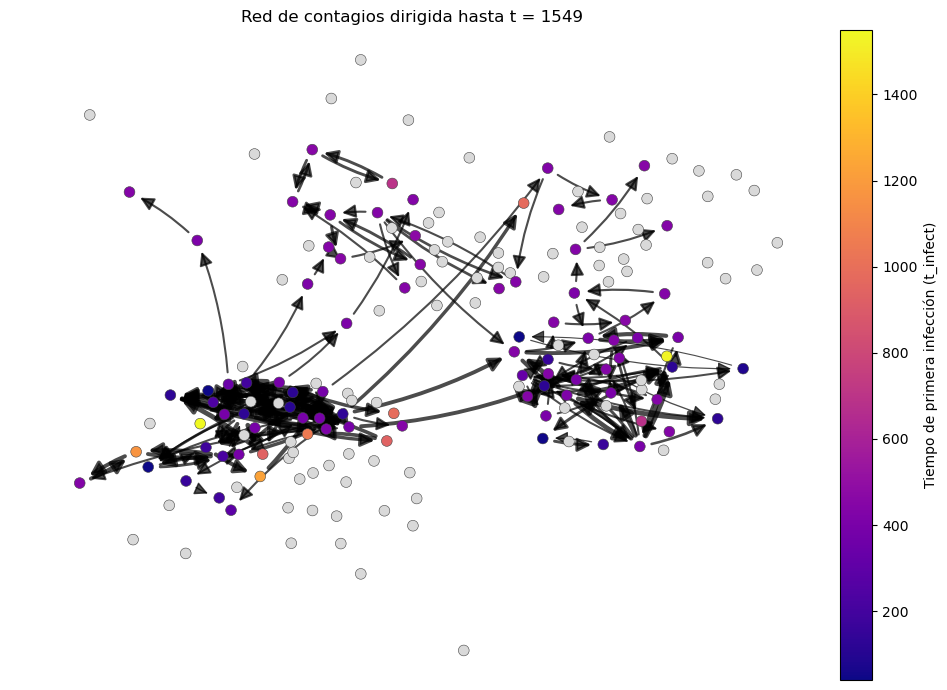

In [5]:
# --- Elección de snapshots (puedes ajustar si quieres otros cortes) ---
if len(inf) > 0:
    TMIN = int(inf["t_infect"].min())
    TMAX = int(inf["t_infect"].max())
    SNAPSHOTS = sorted(set(
        np.linspace(TMIN, TMAX, 8, dtype=int).tolist() + [TMAX]
    ))
else:
    SNAPSHOTS = [0]

print("SNAPSHOTS =", SNAPSHOTS)


# --- Animación en el notebook (opcional) ---
for t_cut in SNAPSHOTS:
    clear_output(wait=True)
    print(f"Mostrando snapshot hasta t = {t_cut}")
    fig = draw_snapshot(t_cut, save=True)  # guarda la imagen en FIGS
    display(fig)
    plt.close(fig)
    time.sleep(1.5)  # segundos de pausa

<h3>6. Busqueda de nodos centrales</h3>

Nodos en G_inf: 180
Aristas en G_inf: 196

Top nodos por PageRank:
46: 0.0409
60: 0.0398
149: 0.0214
74: 0.0199
163: 0.0198
57: 0.0193
23: 0.0192
50: 0.0188
125: 0.0180
33: 0.0176


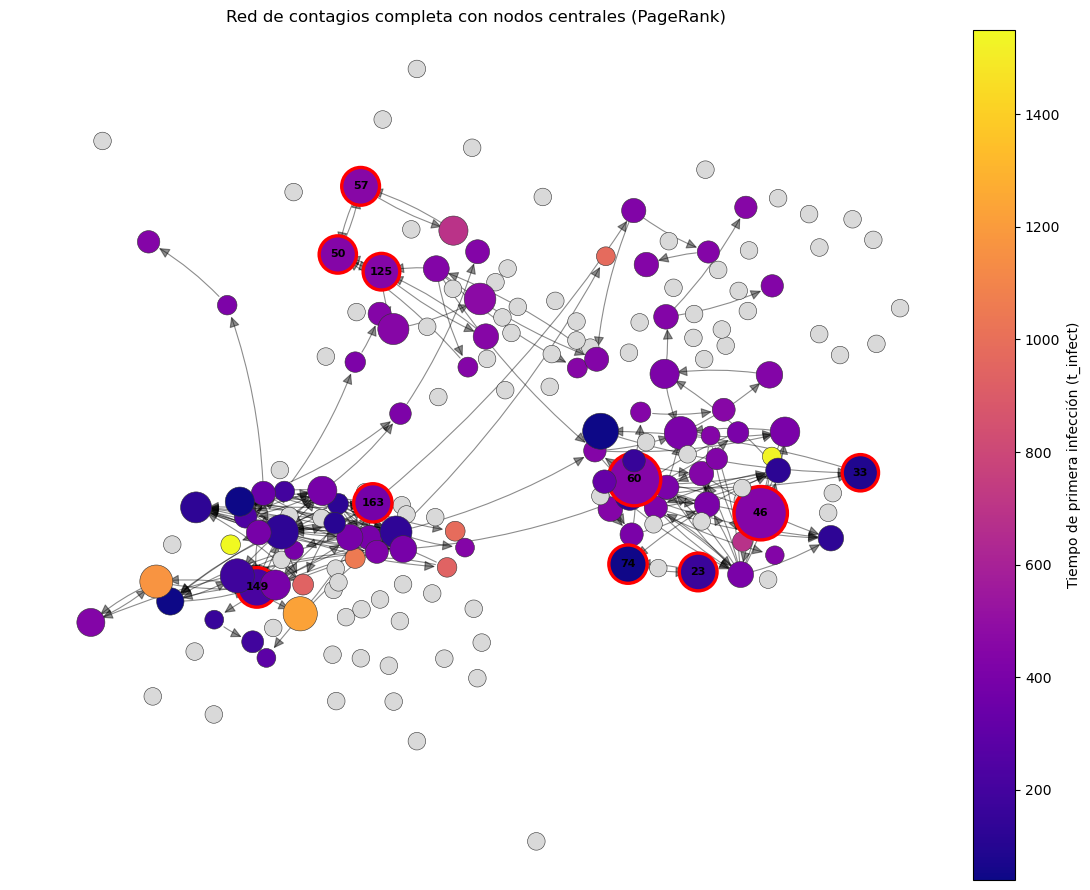


Imagen guardada en: C:\Users\juanf\OneDrive\Documentos\UR\2025-2\grafos me lo tiro\PersonaContagios\PersonaContagios\figs\infections_ALL_pagerank_overlay.png


In [6]:
# --- Construir el grafo de contagios completo ---
G_inf = nx.DiGraph()
ids = nodes["id"].astype(str).tolist()
G_inf.add_nodes_from(ids)

for r in inf.itertuples():
    G_inf.add_edge(r.source, r.target, t_infect=int(r.t_infect))

print("Nodos en G_inf:", G_inf.number_of_nodes())
print("Aristas en G_inf:", G_inf.number_of_edges())

# --- Calcular PageRank ---
pr = nx.pagerank(G_inf, alpha=0.85)  

# Vector de scores en el orden de ids
pr_values = np.array([pr.get(v, 0.0) for v in ids])

if pr_values.max() > 0:
    node_sizes = 80 + 1400 * (pr_values / pr_values.max())
else:
    node_sizes = np.full(len(ids), 80.0)

# Elegimos TOP K nodos por PageRank para resaltar
TOP_K = 10
top_nodes = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
top_set   = {v for v,_ in top_nodes}

print("\nTop nodos por PageRank:")
for v, score in top_nodes:
    print(f"{v}: {score:.4f}")

# Colores de nodos según tiempo de infección final (usando la misma color_by_time)
# Usamos el TMAX_INF (última ventana donde hubo contagio)
T_cut_final = TMAX_INF
node_colors = [color_by_time(v, T_cut_final) for v in ids]

# Borde y grosor especiales para nodos centrales
edgecolors = ["#ff0000" if v in top_set else "#333333" for v in ids]
linewidths = [2.4 if v in top_set else 0.4 for v in ids]

fig, ax = plt.subplots(figsize=(11, 9))

# Dibujar nodos con tamaño proporcional a PageRank
nx.draw_networkx_nodes(
    G_inf, pos,
    nodelist=ids,
    node_color=node_colors,
    node_size=node_sizes,
    linewidths=linewidths,
    edgecolors=edgecolors,
    ax=ax
)

# Dibujar aristas (todas las infecciones)
nx.draw_networkx_edges(
    G_inf, pos,
    ax=ax,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=16,
    width=0.8,
    alpha=0.45,
    connectionstyle="arc3,rad=0.08"
)

# Etiquetas solo para los nodos centrales
labels = {v: v for v, _ in top_nodes}
nx.draw_networkx_labels(
    G_inf, pos,
    labels=labels,
    font_size=8,
    font_weight="bold",
    ax=ax
)

# Barra de color de tiempo de primera infección
sm = plt.cm.ScalarMappable(norm=norm_time, cmap=cmap_time)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Tiempo de primera infección (t_infect)")

ax.set_title("Red de contagios completa con nodos centrales (PageRank)")
ax.axis("off")
fig.tight_layout()

out_path = FIGS / "infections_ALL_pagerank_overlay.png"
fig.savefig(out_path, dpi=180)
plt.show()

print("\nImagen guardada en:", out_path)

<h2>7. Ejecución del algortimo TBFS (BFS Temporal)</h2>

<h3>7.1 Definir la raiz desde donde se ejecutara el algoritmo (paciente cero)</h3>

In [7]:
# Asegurarnos de tipos string por si acaso
inf["source"] = inf["source"].astype(str)
inf["target"] = inf["target"].astype(str)

# Si no hay contagios, no podemos seguir
if len(inf) == 0:
    raise ValueError("No hay contagios en infection_edges.csv; no se puede definir paciente 0.")

# Arista más temprana
idx_min_t = inf["t_infect"].idxmin()
first_edge = inf.loc[idx_min_t]

paciente0 = first_edge["source"]
t_primera_infeccion = int(first_edge["t_infect"])

print("Paciente 0 (aprox):", paciente0)
print("Primera infección registrada en t_infect =", t_primera_infeccion)

Paciente 0 (aprox): 149
Primera infección registrada en t_infect = 40


<h3>7.2 Ejecución de TBFS</h3>

In [8]:
from collections import deque, defaultdict

# Asegurarnos de tipos string
contacts["source"] = contacts["source"].astype(str)
contacts["target"] = contacts["target"].astype(str)

# Ventanas de tiempo disponibles
if "t_start" not in contacts.columns:
    raise ValueError("El archivo contacts.csv no tiene columna 't_start'.")

T_min = int(contacts["t_start"].min())
T_max = int(contacts["t_end"].max())

print("Ventanas temporales: de", T_min, "a", T_max)

# Agrupamos por t_start (como en el SIS)
contacts_by_t = {t: g for t, g in contacts.groupby("t_start")}

# --- TBFS: tiempo mínimo de llegada desde paciente0 ---
# arrival[v] = primer tiempo t en el que puedo llegar a v desde paciente0 respetando el tiempo
arrival = {v: np.inf for v in nodes["id"].astype(str)}
parent  = {v: None for v in nodes["id"].astype(str)}

# Suponemos que el paciente0 está "activo" desde t = T_min (o 0 si quieres)
arrival[paciente0] = T_min

# Recorremos el tiempo hacia adelante
for t in range(T_min, T_max + 1):
    g = contacts_by_t.get(t)
    if g is None or len(g) == 0:
        continue

    # Para cada contacto (u, v) en la ventana t
    for r in g.itertuples():
        u = str(r.source)
        v = str(r.target)

        # Como el contacto es bidireccional, probamos u->v y v->u
        # Sólo permitimos saltar si el origen ya fue alcanzado en un tiempo <= t
        if arrival[u] <= t and arrival[v] > t:
            arrival[v] = t
            parent[v]  = u
        if arrival[v] <= t and arrival[u] > t:
            arrival[u] = t
            parent[u]  = v

print("TBFS temporal terminado.")

# Construimos una serie con resultados temporales (tiempo de llegada)
tbfs_df = (
    pd.DataFrame({
        "id": list(arrival.keys()),
        "t_temporal": [arrival[v] for v in arrival.keys()]
    })
    .replace(np.inf, np.nan)  # NaN = no alcanzable temporalmente
    .sort_values("t_temporal", na_position="last")
)

tbfs_df

Ventanas temporales: de 1 a 36477
TBFS temporal terminado.


,id,t_temporal
149,149,1
155,155,24
157,157,40
169,169,131
158,158,160
...,...,...
52,52,9433
132,132,9542
6,6,17298
22,22,34579


<h2>8. Creación del grafo agregado y calculo de la distancia estática mínima desde el paciente 0 a todos</h2>

In [9]:
# --- Construir grafo agregado (estático) ---
# Lo hacemos no dirigido, cada arista (u, v) está si hubo al menos un contacto
G_agg = nx.Graph()
ids = nodes["id"].astype(str).tolist()
G_agg.add_nodes_from(ids)

for r in contacts.itertuples():
    u = str(r.source)
    v = str(r.target)
    if u != v:
        G_agg.add_edge(u, v)

print("Grafo agregado: |V| =", G_agg.number_of_nodes(), ", |E| =", G_agg.number_of_edges())

# --- Distancias estáticas (número de saltos) desde paciente0 ---
try:
    dist_static = nx.shortest_path_length(G_agg, source=paciente0)
except nx.NetworkXError:
    raise ValueError(f"El paciente0 {paciente0} no se encuentra en G_agg.")

# Convertimos a dict completo (nodos sin camino se marcan como NaN)
dist_static_full = {v: np.nan for v in ids}
for v, d in dist_static.items():
    dist_static_full[v] = d

static_df = (
    pd.DataFrame({
        "id": ids,
        "dist_estatica": [dist_static_full[v] for v in ids]
    })
)

# --- Unimos TBFS temporal con distancia estática ---
comp_df = (
    tbfs_df.merge(static_df, on="id", how="left")
           .sort_values("t_temporal", na_position="last")
)

comp_df

Grafo agregado: |V| = 180 , |E| = 2220


,id,t_temporal,dist_estatica
0,149,1,0
1,155,24,1
2,157,40,1
3,169,131,2
4,158,160,1
...,...,...,...
175,52,9433,2
176,132,9542,3
177,6,17298,2
178,22,34579,3


<h2>9. Calculo del Umbral Epidemico</h2>

In [10]:
# Aseguramos tipos string
contacts["source"] = contacts["source"].astype(str)
contacts["target"] = contacts["target"].astype(str)
nodes["id"]        = nodes["id"].astype(str)

# --- Construir grafo agregado G_agg ---
G_agg = nx.Graph()
G_agg.add_nodes_from(nodes["id"].tolist())

for r in contacts.itertuples():
    u = str(r.source)
    v = str(r.target)
    if u != v:
        G_agg.add_edge(u, v)

print("G_agg: |V| =", G_agg.number_of_nodes(), ", |E| =", G_agg.number_of_edges())

# --- Matriz de adyacencia A ---
A = nx.to_numpy_array(G_agg, nodelist=nodes["id"].tolist(), dtype=float)

# --- Valores propios de A ---
eigvals = np.linalg.eigvals(A)
lambda_max = max(eigvals.real)   # tomamos la parte real por seguridad

print("λ_max(A) ≈", lambda_max)

# --- Umbral epidémico estático ---
tau_c = 1.0 / lambda_max if lambda_max > 0 else np.inf
print("Umbral epidémico estático τ_c ≈ 1/λ_max =", tau_c)

# --- τ efectivo de tu simulación SIS ---
tau = beta / delta   # usa los beta y delta actuales de tu simulación
print("τ (simulado) = β/δ =", tau)

if tau < tau_c:
    print("=> τ < τ_c: la teoría diría que la epidemia NO debería sostenerse en el régimen lineal.")
else:
    print("=> τ ≥ τ_c: la teoría predice que la epidemia puede sostenerse en la red estática agregada.")


G_agg: |V| = 180 , |E| = 2220
λ_max(A) ≈ 30.138406722239864
Umbral epidémico estático τ_c ≈ 1/λ_max = 0.03318025432519217
τ (simulado) = β/δ = 25.0
=> τ ≥ τ_c: la teoría predice que la epidemia puede sostenerse en la red estática agregada.


<h2>Análisis de agregación temporal 
Δt</h2>

In [11]:
# Aseguramos que ya existe arrival (TBFS original)
# arrival[v] = primer tiempo real (t_start) en que se alcanza v desde paciente0
# Si no lo tienes, corre primero el bloque de TBFS original.

contacts["t_start"] = contacts["t_start"].astype(int)

T_min = int(contacts["t_start"].min())
T_max = int(contacts["t_start"].max())

print("Tiempo original: t desde", T_min, "hasta", T_max)

def tbfs_coarse(bin_size):
    """
    Corre un TBFS 'coarse' donde agrupamos las ventanas de tiempo
    en bins de tamaño bin_size (en número de ventanas).
    
    Devuelve:
      arrival_coarse: dict nodo -> primer bin en que es alcanzable
    """
    # Construir contactos agrupados por bin
    contacts = pd.read_csv(P/"contacts.csv").astype({"source": str, "target": str})
    contacts["t_start"] = contacts["t_start"].astype(int)

    T_min_loc = int(contacts["t_start"].min())
    # Definimos bin = floor((t_start - T_min) / bin_size)
    contacts["bin"] = ((contacts["t_start"] - T_min_loc) // bin_size).astype(int)

    contacts_by_bin = {b: g for b, g in contacts.groupby("bin")}

    # Inicialización
    ids = nodes["id"].astype(str).tolist()
    arrival_coarse = {v: np.inf for v in ids}
    arrival_coarse[paciente0] = 0  # paciente0 está en el bin 0 (aprox)

    # TBFS sobre bins
    max_bin = max(contacts_by_bin.keys())

    for b in range(0, max_bin + 1):
        g = contacts_by_bin.get(b)
        if g is None or len(g) == 0:
            continue

        for r in g.itertuples():
            u = str(r.source)
            v = str(r.target)

            # contacto bidireccional en el bin b
            if arrival_coarse[u] <= b and arrival_coarse[v] > b:
                arrival_coarse[v] = b
            if arrival_coarse[v] <= b and arrival_coarse[u] > b:
                arrival_coarse[u] = b

    return arrival_coarse


# --- Barrido de distintos tamaños de bin (Δt) ---
bin_sizes = [1, 2, 5, 10, 100, 1000]  # en número de ventanas (ej: 1*20s, 2*20s, etc.)
results = []

ids = nodes["id"].astype(str).tolist()

reachable_original = {v for v,t in arrival.items() if np.isfinite(t)}

for bs in bin_sizes:
    arrival_c = tbfs_coarse(bs)
    reachable_coarse = {v for v,t in arrival_c.items() if np.isfinite(t)}

    # Nodos extra que salen 'alcanzables' sólo por coarse-graining
    extra_nodes = reachable_coarse - reachable_original

    results.append({
        "bin_size": bs,
        "reach_original": len(reachable_original),
        "reach_coarse": len(reachable_coarse),
        "extra_nodes": len(extra_nodes)
    })

delta_df = pd.DataFrame(results)
delta_df

Tiempo original: t desde 1 hasta 36476


,bin_size,reach_original,reach_coarse,extra_nodes
0,1,180,180,0
1,2,180,180,0
2,5,180,180,0
3,10,180,180,0
4,100,180,180,0
5,1000,180,180,0


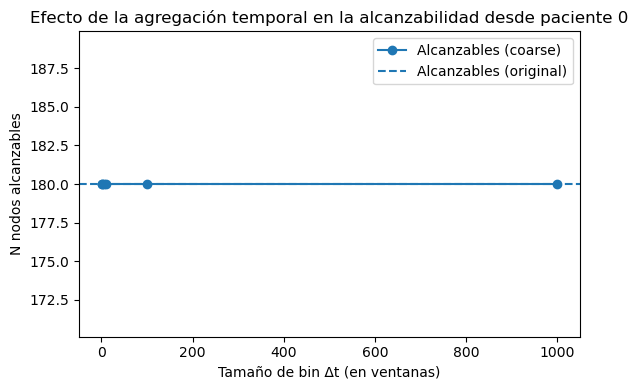

In [12]:
plt.figure(figsize=(6,4))
plt.plot(delta_df["bin_size"], delta_df["reach_coarse"], marker="o", label="Alcanzables (coarse)")
plt.axhline(y=delta_df["reach_original"].iloc[0], linestyle="--", label="Alcanzables (original)")
plt.xlabel("Tamaño de bin Δt (en ventanas)")
plt.ylabel("N nodos alcanzables")
plt.title("Efecto de la agregación temporal en la alcanzabilidad desde paciente 0")
plt.legend()
plt.tight_layout()
plt.show()